In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from matplotlib import pyplot as plt
import seaborn as sns

from peint.data.datamodule import PLMRDataModule
from peint.data.datasets.lept import EncodedLEPTDataset
from peint.models.modules.lept_module import LEPTModule
from peint.models.nets.lept import LEPT

from evo.dataset import ComplexCherriesDataset
from evo.tokenization import Vocab
from esm.data import Alphabet

from tqdm import tqdm
tqdm.pandas()

In [ ]:
# Load trained joint model from checkpoint
ckpt_dir = Path("/accounts/projects/yss/stephen.lu/peint/logs/train/runs/2025-10-31_15-51-29/checkpoints")
ckpt_path = ckpt_dir / "last.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# create a fresh peint model with the same hyperparameters as the training run
vocab = Vocab.from_esm_alphabet(Alphabet.from_architecture("ESM-1b"))
module: LEPTModule = LEPTModule.load_from_checkpoint(ckpt_path, map_location=device, strict=True)
module = module.eval()

Using device: cuda


/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


In [7]:
import tempfile

def dataloader_from_transitions(transitions, batch_size=32, mask_prob=0.0, datapath=None):
    if datapath is None:
        datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
        with open(datafile.name, "w") as f:
            f.write("{0} transitions\n".format(len(transitions)))
            f.write("\n".join(transitions))
        datapath = datafile.name

    dataset = EncodedLEPTDataset(
        dataset=ComplexCherriesDataset(data_file=datapath, min_t=0., chain_id_offset=1),
        vocab=vocab,
        swap_prob=0.0,
        sep_token=".",
    )
    dataloader = PLMRDataModule(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )._dataloader_template(dataset=dataset, training=False)
    return dataloader

def infer_log_likelihoods(dataloader, module, n_batches = 100):
    # run inference on the dataloader
    lls, bls, ppl = [], [], []
    for batch in tqdm(dataloader, desc="Inference"):
        batch = [b.to(device) for b in batch]
        x, y, t, x_sizes, y_sizes = batch

        # transition objective
        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            Z_x = module.net.encode(x, x_sizes)
            Z_y_hat = module.net.exp(Z_x, t=t)
            y_attn_mask = (y != vocab.pad_idx).long()
            logits = module.net.decoder(y[:, :-1], Z_y_hat, y_attn_mask[:, :-1])

        nll = F.cross_entropy(
            logits.transpose(1, 2),
            y[:, 1:],
            ignore_index=vocab.pad_idx,
            reduction="none",
        )  # (bs, seq_len-1)

        yt_mask = y_attn_mask[:, :-1].bool()
        ll = -nll * yt_mask.float()
        ll = ll.sum(dim=-1)
        lls.append(ll.detach().cpu().numpy())

        bls.append(t.detach().cpu().numpy())
        nll_mean = (nll * yt_mask.float()).sum(dim=-1) / yt_mask.float().sum(dim=-1)
        ppl.append(torch.exp(nll_mean).detach().cpu().numpy())

        n_batches -= 1
        if n_batches == 0:
            break

    lls = np.concatenate(lls)
    bls = np.concatenate(bls)
    ppl = np.concatenate(ppl)
    return lls, bls, ppl

def decode_sequence_from_toks(toks):
    tokens = []
    for tok in toks:
        if tok == vocab.bos_idx:
            continue
        if tok == vocab.eos_idx or tok == vocab.pad_idx:
            break
        tokens.append(vocab.token(tok))
    return "".join(tokens)    

In [8]:
# load the test dataset
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/aa/d4.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)
lls, bls, ppl = infer_log_likelihoods(dataloader, module, n_batches=-1)

Inference:   0%|                                                                                                            | 0/1888 [00:00<?, ?it/s]/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  warnings.warn(
Inference: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 1888/1888 [34:09<00:00,  1.09s/it]


In [9]:
print('test perplexity: ', np.mean(ppl))
print(lls)

# save branch, lls, and ppls to a dataframe
df = pd.DataFrame({
    "branch": bls[:,0],
    "log_likelihood": lls,
    "perplexity": ppl,
})

df.to_csv("lept_model_d4.csv", index=False)

test perplexity:  1.5579735
[ -87.020004 -111.51966  -129.29486  ... -189.8838   -163.27708
 -139.3453  ]


In [21]:
df

,branch,log_likelihood,perplexity,method,time_bin
0,1.823280,-121.40933,1.695312,peint,14.0
1,1.781804,-100.05171,1.533529,peint,14.0
2,1.087145,-72.75749,1.364693,peint,8.0
3,0.753409,-70.13519,1.349485,peint,5.0
4,3.752910,-165.15057,2.056862,peint,29.0
...,...,...,...,...,...
123370,0.605470,-171.71738,2.051318,lept,4.0
123371,2.354337,-140.44402,1.851475,lept,18.0
123372,1.782549,-189.88380,2.299803,lept,14.0
123373,1.503284,-163.27708,2.046493,lept,11.0


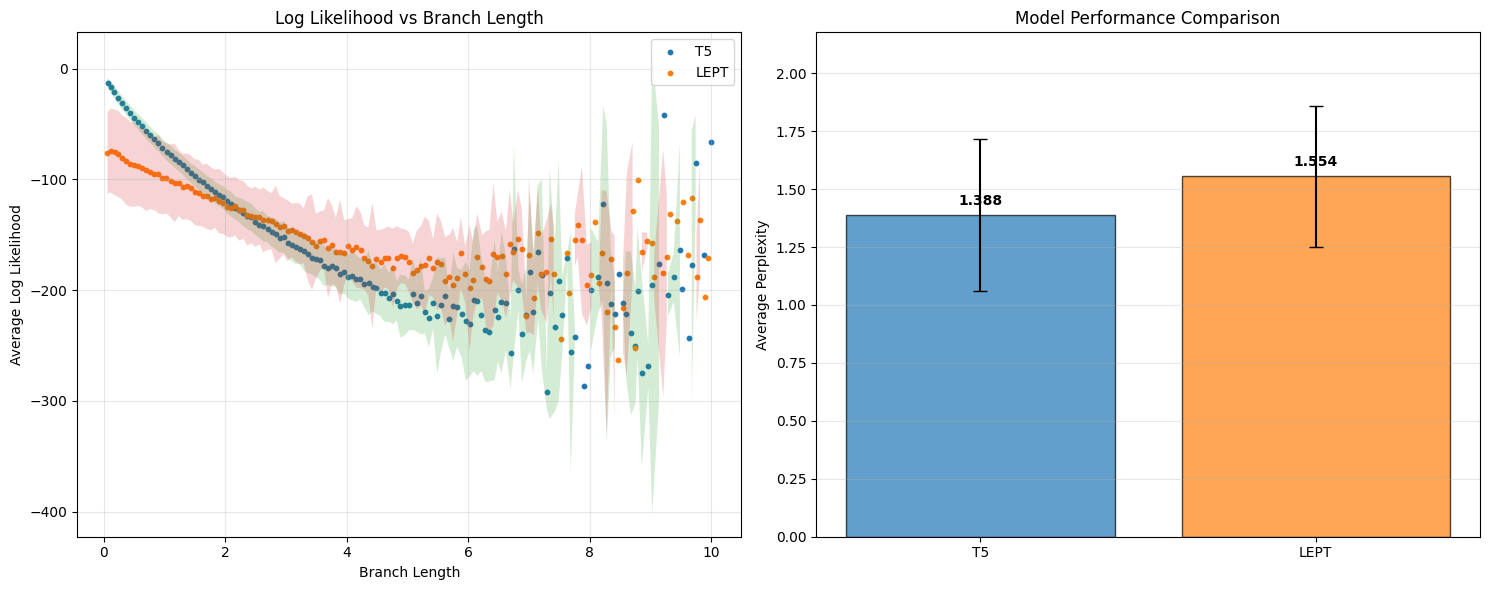

In [40]:
peint_df = pd.read_csv("codon_model_d4.csv")
lept_df = pd.read_csv("lept_model_d4.csv")

# plot the binned likelihoods according to the branch length
quantile_10 = pd.concat([peint_df.branch, lept_df.branch]).quantile(0.05)
peint_df["time_bin"] = peint_df.branch // quantile_10.astype(float)
lept_df["time_bin"] = lept_df.branch // quantile_10.astype(float)

# remove all with time_bin > 10
peint_df = peint_df[peint_df.branch <= 10.0]
lept_df = lept_df[lept_df.branch <= 10.0]

bin_cols = ['time_bin', 'branch', 'log_likelihood']
binned_peint_df = peint_df[bin_cols].groupby("time_bin").mean()
binned_lept_df = lept_df[bin_cols].groupby("time_bin").mean()

# Add confidence intervals as shaded areas
binned_peint_std = peint_df[bin_cols].groupby("time_bin").std()
binned_lept_std = lept_df[bin_cols].groupby("time_bin").std()

# fig, ax = plt.subplots(figsize=(10, 6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left plot - existing likelihood vs branch length plot
ax1.scatter(binned_peint_df.branch, binned_peint_df.log_likelihood, label="T5", s=10)
ax1.scatter(binned_lept_df.branch, binned_lept_df.log_likelihood, label="LEPT", s=10)

# Add confidence intervals
ax1.fill_between(
    binned_peint_df.branch,
    binned_peint_df.log_likelihood - binned_peint_std.log_likelihood,
    binned_peint_df.log_likelihood + binned_peint_std.log_likelihood,
    alpha=0.2,
)

ax1.fill_between(
    binned_lept_df.branch,
    binned_lept_df.log_likelihood - binned_lept_std.log_likelihood,
    binned_lept_df.log_likelihood + binned_lept_std.log_likelihood,
    alpha=0.2,
)

ax1.set_xlabel("Branch Length")
ax1.set_ylabel("Average Log Likelihood")
ax1.set_title("Log Likelihood vs Branch Length")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot - average perplexity comparison with error bars
models = ['T5', 'LEPT']
avg_perplexities = [peint_df.perplexity.mean(), lept_df.perplexity.mean()]
std_perplexities = [peint_df.perplexity.std(), lept_df.perplexity.std()]
colors = ['tab:blue', 'tab:orange']

bars = ax2.bar(models, avg_perplexities, yerr=std_perplexities, color=colors, alpha=0.7, 
               edgecolor='black', linewidth=1, capsize=5)

# Add value labels on bars
for bar, value in zip(bars, avg_perplexities):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(std_perplexities) * 0.1,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

ax2.set_ylabel("Average Perplexity")
ax2.set_title("Model Performance Comparison")
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, max(avg_perplexities) * 1.4)

plt.tight_layout()
plt.show()


In [18]:
df.head()

,branch,log_likelihood,perplexity,method
0,1.823280,-121.40933,1.695312,peint
1,1.781804,-100.05171,1.533529,peint
2,1.087145,-72.75749,1.364693,peint
3,0.753409,-70.13519,1.349485,peint
4,3.752910,-165.15057,2.056862,peint
